In [1]:
!pip3 install opencv-python
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import tensorflow as tf
import cv2
import numpy as np
import math
from matplotlib import pyplot as plt
import seaborn as sns
import time
import os

/Users/prakhar/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
patch_size = 32
kernel_size = patch_size
image_size = 256
descriptor_dimension = 4

max_rotation = 360
rotation_multiple = 5
max_skew = 0

margin = 1.5
threshold = 0.4
learning_rate = 0.1e-2
optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
cos_sim = tf.keras.losses.CosineSimilarity()
batch_size = 1
epochs = 100000
num_filters = 4
model_path = "filters_model.h5"
backup_model_path = "backup_filters_model.h5"

In [4]:
centre_to_top_right = np.array([[1,0,-math.ceil(image_size/2)],
                                [0,1,-math.ceil(image_size/2)],
                                [0,0,1]])
top_right_to_centre = np.array([[1,0,math.ceil(image_size/2)],
                                [0,1,math.ceil(image_size/2)],
                                [0,0,1]])

patch_centre_to_top_right = np.array([[1,0,-math.ceil(patch_size/2)],
                                [0,1,-math.ceil(patch_size/2)],
                                [0,0,1]])
patch_top_right_to_centre = np.array([[1,0,math.ceil(patch_size//2)],
                                [0,1,math.ceil(patch_size//2)],
                                [0,0,1]])

def create_rotational_matrix(rotation, axis = "z"):
    rotation = np.radians(rotation)
    s = np.sin(rotation)
    c = np.cos(rotation)
    if axis == "z":
        return np.array([[c, -s, 0],
                          [s, c, 0],
                          [0, 0, 1]])
        
def create_skew_matrix(skew_x, skew_y):
     return np.array([[1, skew_x, 0],
                     [skew_y, 1, 0],
                     [0, 0, 1]])

In [5]:
def get_fixed_homography_matrix(val):
    rotation = rotation_multiple*val
    # rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), patch_centre_to_top_right))
    return homography_matrix

In [6]:
def get_random_homography_matrix(whole_image =False):
    rotation = np.random.uniform(0,max_rotation)
    rotation = (rotation//rotation_multiple) * rotation_multiple
    skew_x = np.random.uniform(0,max_skew)
    skew_y = np.random.uniform(0,max_skew)

    rotation_matrix = create_rotational_matrix(rotation)
    skew_matrix = create_skew_matrix(skew_x, skew_y)
    homography_matrix = np.matmul(top_right_to_centre if whole_image else patch_top_right_to_centre, np.matmul(np.matmul(skew_matrix, rotation_matrix), centre_to_top_right if whole_image else  patch_centre_to_top_right))
    return homography_matrix

In [7]:
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, image_dir_path, batch_size = 128):
        
        self.img_list = []
        for image in os.listdir(image_dir_path):
            if image == ".DS_Store":
                continue
            
            img = cv2.imread(os.path.join(image_dir_path, image))
            img = cv2.resize(img, (image_size, image_size))
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
            img = img/255
            self.img_list.append(img)
            
        self.batchsize = batch_size  
                
    def __len__(self):
        return math.ceil(((image_size - patch_size)**2)/self.batchsize)
        
    def __getitem__(self, batch):
        original_images = []
        matches = []
        non_matches = []
        for _ in range(self.batchsize):
            current_image_no = np.random.randint(0, len(self.img_list))
            current_image = self.img_list[current_image_no]
           
            orb= cv2.ORB_create(100)
            kp = orb.detect((np.repeat(np.expand_dims(current_image,-1),3,-1)*255).astype(np.uint8))
            k=0
            got=False
            while(not got):
                k=np.random.choice(kp)
                if(k.pt[0] >patch_size and k.pt[1] >patch_size and k.pt[1]<image_size-(patch_size )and k.pt[0]<image_size-(patch_size)):
                    got=True
            x= k.pt[0]
            y= k.pt[1]
            
            current_patch = current_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            # current_patch = cv2.blur(current_patch, (3,3))
            #transform image 
            H=get_random_homography_matrix(True)
            transformed_image = cv2.warpPerspective(current_image, H, (image_size, image_size))
            points_to_transform = np.array([[x, y]], dtype='float32')
            points_to_transform = np.expand_dims(points_to_transform, axis=0)  # Add an extra dimension for the transformation
            transformed_points = cv2.perspectiveTransform(points_to_transform, H)

            # transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            # transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            x= transformed_points[0][0][0]
            y= transformed_points[0][0][1]
        
            transformed_current_patch = transformed_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            current_patch = np.expand_dims(current_patch, axis = -1)
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            # test_original_image =(np.repeat(np.expand_dims(current_image,-1),3,-1)*255).astype(np.uint8)
            # test_transformed_image = (np.repeat(np.expand_dims(transformed_image,-1),3,-1)*255).astype(np.uint8)
            # cv2.circle(test_original_image,(int( k.pt[0]), int(k.pt[1])),3,(255,0,0))
            # cv2.circle(test_transformed_image,(int(transformed_points[0][0][0]), int(transformed_points[0][0][1])),3,(255,0,0))
            
            original_images.append(current_patch)
            matches.append(transformed_current_patch)
            
            # X = np.random.randint(0,image_size - patch_size)
            # Y = np.random.randint(0,image_size - patch_size)
            # random_image_no = np.random.randint(0, len(self.img_list))
            # random_image = self.img_list[random_image_no]
            # while(x==X & y==Y & random_image_no == current_image_no):
            #     X = np.random.randint(0,image_size - patch_size)
            #     Y = np.random.randint(0,image_size - patch_size)
            k_r=k
            got=False
            while(k.pt == k_r.pt or (not got)):
                k_r=np.random.choice(kp)
                if(k_r.pt[0] >patch_size and k_r.pt[1] >patch_size and k_r.pt[1]<image_size-(patch_size)and k_r.pt[0]<image_size-(patch_size)):
                    got=True
            
            H=get_random_homography_matrix(True)
            transformed_image = cv2.warpPerspective(current_image, H, (image_size, image_size))
            points_to_transform = np.array([[k_r.pt[0], k_r.pt[1]]], dtype='float32')
            points_to_transform = np.expand_dims(points_to_transform, axis=0)  # Add an extra dimension for the transformation
            transformed_points = cv2.perspectiveTransform(points_to_transform, H)

            # transformed_current_patch = cv2.warpPerspective(current_patch, get_random_homography_matrix(), (patch_size, patch_size))
            # transformed_current_patch = cv2.blur(transformed_current_patch, (3,3))
            x= transformed_points[0][0][0]
            y= transformed_points[0][0][1]
            transformed_current_patch = transformed_image[int(y-patch_size/2):int(y+patch_size/2), int(x-patch_size/2):int(x+patch_size/2)]
            transformed_current_patch = np.expand_dims(transformed_current_patch, axis = -1)
            non_matches.append(transformed_current_patch)
        
            original_images = np.array(original_images)
            matches = np.array(matches)
            non_matches = np.array(non_matches)
            
            # original_images = np.array(original_images > threshold, dtype=np.double)
            # matches = np.array(matches > threshold, dtype=np.double)
            # non_matches = np.array(non_matches > threshold, dtype=np.double)
            
        return original_images, matches, non_matches

Test data generation


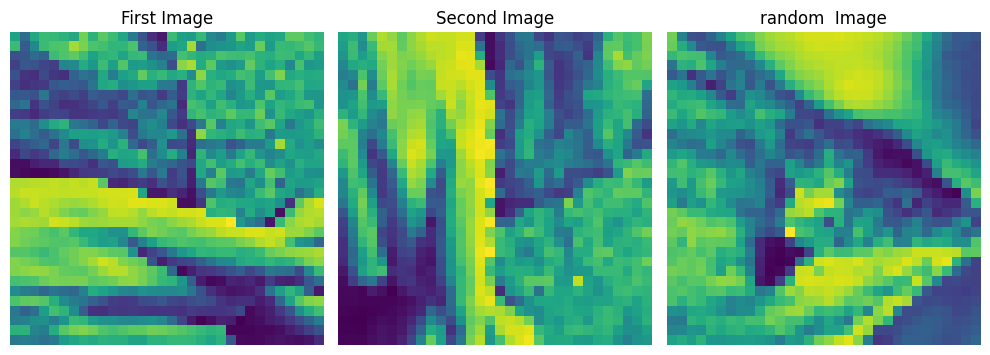

In [8]:
test_data_gen = CustomDataGenerator("real_images", batch_size)
print("Test data generation")
o,t,r = test_data_gen.__getitem__(0)
fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(o[0]*1)
# axes[0].imshow(o[0]*255)
axes[0].set_title('First Image')
axes[0].axis('off')

# Plot the second image
axes[1].imshow(t[0]*1)
# axes[1].imshow(t[0]*255)
axes[1].set_title('Second Image')
axes[1].axis('off')

axes[2].imshow(r[0]*1)
# axes[1].imshow(t[0]*255)
axes[2].set_title('random  Image')
axes[2].axis('off')

# Display the plot
plt.tight_layout()
plt.show()

In [9]:
# class ChannelNormalization(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ChannelNormalization, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.l2_normalize(inputs, axis=-1)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ChannelNormalization, self).build(input_shape)
        
#     def get_config(self):
#         return super(ChannelNormalization, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [10]:
# class ClippingLayer(tf.keras.layers.Layer):
#     def __init__(self):
#         super(ClippingLayer, self).__init__()

#     def call(self, inputs):
#         return tf.keras.backend.clip(inputs, min_value=0.0, max_value=256.0)
    
#     def compute_output_shape(self, input_shape):
#         return input_shape
    
#     def build(self, input_shape):
#         super(ClippingLayer, self).build(input_shape)
        
#     def get_config(self):
#         return super(ClippingLayer, self).get_config()
    
#     @classmethod
#     def from_config(cls, config):
#         instance = cls()
#         return instance

In [11]:
# def get_model(input_shape, descriptor_dimension):
#     inp = tf.keras.layers.Input(input_shape)
#     out = tf.keras.layers.Conv2D(descriptor_dimension, kernel_size)(inp)
#     # out = ClippingLayer()(out)
#     out = ChannelNormalization()(out)
    
#     model = tf.keras.models.Model(inputs = inp, outputs = out)
#     return model

In [12]:
# def custom_loss(original_desc, matches, non_matches):
#     original_desc = tf.squeeze(original_desc)
#     matches = tf.squeeze(matches)
#     non_matches = tf.squeeze(non_matches)
    
#     return tf.reduce_mean((1 - tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(original_desc, tf.transpose(matches))) + \
#                             abs(tf.matmul(matches, tf.transpose(non_matches))))
    

In [13]:
# model = get_model((patch_size, patch_size, 1), descriptor_dimension)
# model.summary()

In [14]:
# data_gen = CustomDataGenerator("test/img/cinema1.jpeg", batch_size)

# for epoch in range(epochs):
#     epoch_loss = 0
#     print(f"Epoch {epoch} starting...")
#     for batch in range(data_gen.__len__()):
#         all_patches, matches, non_matches = data_gen.__getitem__(batch)
#         with tf.GradientTape() as tape:
#             all_predictions = model(all_patches)
#             matches_predictions = model(matches)
#             non_matches_predictions = model(non_matches)
#             loss = custom_loss(all_predictions, matches_predictions, non_matches_predictions)
#             # print(loss)
#             epoch_loss += loss
#             gradients = tape.gradient(loss, model.trainable_variables)
#             optimizer.apply_gradients(zip(gradients, model.trainable_variables))
        
#         # if batch%5==0:
#         #     print(loss.numpy())
#     # val_generator.on_epoch_end()
    
#     try:
#         model.save(model_path)
#         model.save(backup_model_path)
#     except Exception as e:
#         print("========= Note ================")
#         print("cant save last model")
#         print(e)
    
#     print(epoch_loss.numpy()/data_gen.__len__())
#     epoch_loss = 0

In [27]:
val_data_gen = CustomDataGenerator("real_images", batch_size)

In [16]:
# og, match, no_match = val_data_gen.__getitem__(0)
# fig, ax = plt.subplots(ncols=3, figsize = (11,5))
# # sns.heatmap(og[0,:,:,0], ax = ax[0], cbar = False, vmin=0, vmax=1)
# sns.heatmap(match[0,:,:,0], ax = ax[1], cbar = False, vmin=0, vmax=1)
# sns.heatmap(no_match[0,:,:,0], ax = ax[2], cbar = False, vmin=0, vmax=1)

In [17]:
def inverse_sigmoid(x):
    epsilon = 1e-7  # to avoid division by zero and log of zero
    y = tf.clip_by_value(x, epsilon, 1 - epsilon)
    return tf.math.log(y / (1 - y))

In [18]:
def get_gaussian_kernel(shape=(3,3), sigma=0.5):
    """build the gaussain filter"""
    m,n = [(ss-1.)/2. for ss in shape]
    x = tf.expand_dims(tf.range(-n,n+1,dtype=tf.float32),1)
    y = tf.expand_dims(tf.range(-m,m+1,dtype=tf.float32),0)
    h = tf.exp(tf.math.divide_no_nan(-((x*x) + (y*y)), 2*sigma*sigma))
    h = tf.math.divide_no_nan(h,tf.reduce_sum(h))
    h =tf.cast(h,dtype=tf.double)
    return h

def gaussian_blur(inp, shape=(3,3), sigma=0.5):
    """Convolve using tf.nn.depthwise_conv2d"""
    org_shape =tf.shape(inp)
    inp = tf.reshape(inp,( 1,*org_shape,1))
    in_channel = tf.shape(inp)[-1]
    k = get_gaussian_kernel(shape,sigma)
    k = tf.expand_dims(k,axis=-1)
    k = tf.repeat(k,in_channel,axis=-1)
    k = tf.reshape(k, (*shape, in_channel, 1))
    # using padding same to preserve size (H,W) of the input
    conv = tf.nn.depthwise_conv2d(inp, k, strides=[1,1,1,1],padding="SAME")
    conv = tf.reshape(conv,org_shape)
    return conv

def arrange_filter(filter):
    mx = np.max(filter)
    mn = np.min(filter)
    filter = filter - mn
    filter = (filter/mx)*255
    return filter

In [19]:
def custom_loss(desc1_og_img, desc1_trans_img, desc1_rand_img):
    
    # desc1_og_img_sum = tf.reduce_sum(desc1_og_img)
    # desc1_trans_img_sum = tf.reduce_sum(desc1_trans_img)
    # desc1_rand_img_sum = tf.reduce_sum(desc1_rand_img)
    # print(desc1_og_img_sum)
    # print(desc1_trans_img_sum)
    # print(desc1_rand_img_sum)
    # descriptor_loss = tf.maximum(0, tf.reduce_sum(abs(desc1_og_img - desc1_trans_img)) - tf.reduce_sum(abs(desc1_rand_img - desc1_og_img)) + margin)
    # filter_loss=0
    # for i in range(int(360/rotation_multiple)):
    # h_m = get_random_homography_matrix()
    # changed_sigmoid_filter = cv2.warpPerspective(sigmoid_filter.numpy(), h_m, (patch_size, patch_size))
    # filter_loss = filter_loss+1 - -cos_sim(tf.reshape(changed_sigmoid_filter, [-1]), tf.reshape(sigmoid_filter, [-1]))
    
#     loss = (descriptor_loss + (0.5*filter_loss))/5
    # filter_numbers = np.random.choice(np.arange(0, len(filters)), size=2, replace=False)
    # filter1 = tf.keras.activations.tanh(filters[filter_numbers[0]])
    # filter2 = tf.keras.activations.tanh(filters[filter_numbers[1]])

    # filter_loss = -cos_sim(filter1, filter2) + 1
    
    # loss = (descriptor_loss+ filter_loss/6 )/3.4
    
    loss = tf.maximum(0.0,cos_sim(desc1_og_img,desc1_trans_img) - cos_sim(desc1_og_img,desc1_rand_img)+ margin)
    
    # print(f"""
    #       descriptor loss: {descriptor_loss}
    #       filter loss: {filter_loss}
    #       loss: {loss}""")
    return loss

In [20]:
filters = tf.Variable(tf.random.uniform(shape=( patch_size, patch_size,num_filters), minval=-2, maxval=2, dtype=tf.double))
filters.shape

TensorShape([32, 32, 4])

In [29]:
net_loss = 0
for i in range(epochs):
    og, match, no_match = val_data_gen.__getitem__(0)
    with tf.GradientTape() as tape:     
        # og = tf.reshape(og, [-1])
        # match = tf.reshape(match, [-1])
        # no_match = tf.reshape(no_match, [-1])
        try:    
            filters_batch = tf.repeat(tf.reshape(tf.keras.activations.tanh(filters),(1,patch_size,patch_size,num_filters)),batch_size,0)
            og_filter_channel = tf.repeat(og,num_filters,-1)
            match_filter_channel = tf.repeat(match,num_filters,-1)
            no_match_filter_channel = tf.repeat(no_match,num_filters,-1)
            # print(og.shape)
            # print(filters_batch.shape)
            # print('no match filter ',no_match_filter_channel.shape)
            # break
            
            og_vector = tf.reduce_mean(tf.multiply(og_filter_channel,filters_batch),[1,2])
            match_vector = tf.reduce_mean(tf.multiply(match_filter_channel,filters_batch),[1,2])
            no_match_vector = tf.reduce_mean(tf.multiply(no_match_filter_channel,filters_batch),[1,2])
            
            # print('og vector',og_vector.shape)
            
            # break
            loss = custom_loss(og_vector, match_vector, no_match_vector)
            # print('loss',loss)
            gradients = tape.gradient(loss, [filters])
            net_loss = loss+net_loss
            # print('grad',gradients)
            optimizer.apply_gradients(zip(gradients, [filters]))
        except Exception as e:
            # print('error',e)
            continue
       
    if i%500 == 0 and i != 0:
        print('net loss', net_loss/500)
        # filters.assign_add(tf.Variable(tf.constant(tf.random.uniform(shape=( patch_size, patch_size,num_filters), minval=-0.05*net_loss, maxval=0.05*net_loss, dtype=tf.double))))
        net_loss =0
        # sns.heatmap(filter,cbar=False)
        # for filter_number, filter in enumerate(filters):
        t = time.time()
        cv2.imwrite(f"filters/filter_{int(t)}_{0}.png", np.array(arrange_filter(filters)))
        np.save(f"learned_filters/learned_filters_chnnel_{num_filters}.npy", filters.numpy())

            # plt.savefig(f"filters/filter1_{int(t)}.jpg")
            # filter = tf.Variable(tf.keras.activations.sigmoid(filter))
            # optimizer = tf.keras.optimizers.Adam(learning_rate = learning_rate)
            
            # filter.assign(gaussian_blur(filter))
        # print(loss.numpy())
    # if i%1000 == 0 and i != 0:
        # for filter_number, filter in enumerate(filters):
        #     filter.assign(gaussian_blur(filter))
        

net loss tf.Tensor(0.6620090346867787, shape=(), dtype=float64)
net loss tf.Tensor(0.6699038097014602, shape=(), dtype=float64)
net loss tf.Tensor(0.7173230930640991, shape=(), dtype=float64)
net loss tf.Tensor(0.6836328239870034, shape=(), dtype=float64)
net loss tf.Tensor(0.6689741924392362, shape=(), dtype=float64)
net loss tf.Tensor(0.6826403692331489, shape=(), dtype=float64)
net loss tf.Tensor(0.6971838284849079, shape=(), dtype=float64)
net loss tf.Tensor(0.7232760244403823, shape=(), dtype=float64)
net loss tf.Tensor(0.7001180683883146, shape=(), dtype=float64)
net loss tf.Tensor(0.6811709169675868, shape=(), dtype=float64)
net loss tf.Tensor(0.699501747383945, shape=(), dtype=float64)
net loss tf.Tensor(0.6531006305063085, shape=(), dtype=float64)
net loss tf.Tensor(0.699356363908288, shape=(), dtype=float64)
net loss tf.Tensor(0.7005375315312071, shape=(), dtype=float64)
net loss tf.Tensor(0.663631329730717, shape=(), dtype=float64)
net loss tf.Tensor(0.6836099506436, shape=(

In [22]:
sns.heatmap(filters)
t = time.time()
plt.savefig(f"filters/filter1_{int(t)}.jpg")

ValueError: Must pass 2-d input. shape=(32, 32, 4)

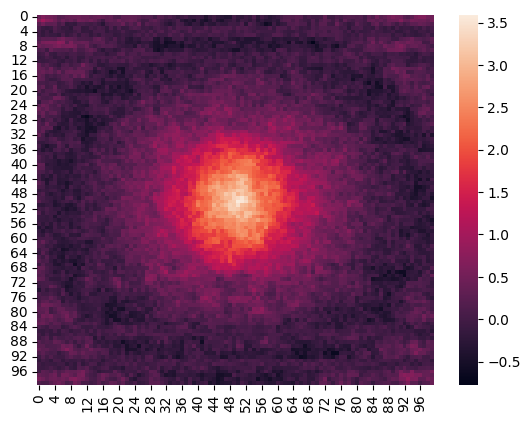

In [ ]:

sns.heatmap(filters[2])
t = time.time()
plt.savefig(f"filters/filter1_{int(t)}.jpg")